# S2 v2: scGPT + GRN Bias — Principled Loss

**Changes from v1:**
1. **Delta-based loss** — train on `(pred - ctrl)` vs `(target - ctrl)`
2. **Variance-based gene weighting** — `w_g = Var_across_perturbations(delta_g)`, no hardcoding
3. **Autofocus loss** (GEARS, Roohani et al. 2024) — `(MSE)^gamma` amplifies large-effect genes
4. **Direction-aware loss** (GEARS) — penalizes wrong sign of predicted perturbation effect
5. **Separate alpha LR** (100x) + per-layer alpha + alpha_init=1.0
6. **Cosine annealing** scheduler
7. **Gradient + magnitude diagnostics**

https://arxiv.org/html/2506.22641v1 used or not?

In [1]:
# 1.1 Imports + GPU
import sys, os, subprocess

def select_free_gpu(min_free_mb=10000):
    try:
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=index,memory.free,name', '--format=csv,nounits,noheader'],
            capture_output=True, text=True
        )
        gpus = []
        for line in result.stdout.strip().split('\n'):
            parts = line.split(',')
            gpus.append((int(parts[0]), int(parts[1]), parts[2].strip()))
        for idx, free, name in reversed(gpus):
            if free >= min_free_mb:
                os.environ['CUDA_VISIBLE_DEVICES'] = str(idx)
                print(f'Selected GPU {idx}: {name} ({free} MB free)')
                return idx
        print('WARNING: no GPU with enough free memory')
    except Exception as e:
        print(f'GPU detection failed: {e}')
    return None

select_free_gpu()

import time, copy, random, json, warnings
from pathlib import Path
from typing import Dict, List, Optional

import numpy as np
import torch
import scanpy as sc
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

import scgpt as scg
from scgpt.model import TransformerGenerator
from scgpt.tokenizer import GeneVocab
from scgpt.loss import masked_mse_loss
from scgpt.utils import set_seed, map_raw_id_to_vocab_id

matplotlib.rcParams['savefig.transparent'] = False
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    print(f'Device: {torch.cuda.get_device_name(0)}')
    print(f'  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Selected GPU 7: Tesla V100-SXM2-32GB (32501 MB free)


/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/conda_envs/scgpt/lib/python3.10/site-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/vocab/__init__.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warning by calling the following at the beginnign of your scripts: `import torchtext; torchtext.disable_torchtext_deprecation_warning()`
  warnings.warn(torchtext._TORCHTEXT_DEPRECATION_MSG)
/conda_envs/scgpt/lib/python3.10/site-packages/torchtext/utils.py:4: UserWarning: 
/!\ IMPORTANT WARNING ABOUT TORCHTEXT STATUS /!\ 
Torchtext is deprecated and the last released version will be 0.18 (this one). You can silence this warn

Device: Tesla V100-SXM2-32GB
  Memory: 34.1 GB


In [2]:
# 1.2 Reproducibility
def setup_environment(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.manual_seed(seed)
    sc.settings.seed = seed
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

setup_environment(42)

In [3]:
# 2.1 Paths
data_path = '../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad'
model_dir = '../../model_checkpoints/scGPT_human'

celloracle_dir = '../CellOracle/celloracle_grn_20260305_221104'
M_MATRIX_CSV = f'{celloracle_dir}/K562_GRN_M_matrix.csv'
M_TARGET_GENES = f'{celloracle_dir}/K562_GRN_M_target_genes.csv'
M_SOURCE_TFS = f'{celloracle_dir}/K562_GRN_M_source_TFs.csv'

In [4]:
# 2.2 Hyperparameters
embsize = 128
d_hid = 512
nlayers = 4
nhead = 4
n_layers_cls = 3

epochs = 25
lr = 1e-4
alpha_lr = 1e-2           # 100x for alpha
batch_size = 256
eval_batch_size = 256
early_stop = 10
dropout = 0.2
amp = True

# GRN bias
ALPHA_INIT = 1.0
M_NORMALIZE = True

# Loss config
GAMMA = 2.0               # autofocus exponent (GEARS default ~2; Scouter uses 0)
LAMBDA_DIR = 0.05         # direction-aware loss weight (GEARS: 0.05 for Norman)

MLM = True
CLS = False
CCE = False
MVC = False
ECS = False

pad_token = '<pad>'
special_tokens = [pad_token, '<cls>', '<eoc>']
pad_value = 0
pert_pad_id = 0
include_zero_gene = 'all'
max_seq_len = 1536
log_interval = 50

save_dir = Path(f'./save/norman_grn_bias_weight_v2-{time.strftime("%b%d-%H-%M")}/')
save_dir.mkdir(parents=True, exist_ok=True)
print(f'Save directory: {save_dir}')

logger = scg.logger
scg.utils.add_file_handler(logger, save_dir / 'run.log')

Save directory: save/norman_grn_bias_weight_v2-Mar06-17-21


## 3. Data Loading & Preprocessing

In [5]:
# 3.1 Load + normalize
adata = sc.read_h5ad(data_path)
adata.obs['split'] = adata.obs['gears_split']
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

if 'gene_name' in adata.var:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()
print(f'Genes: {adata.var_names[:5].tolist()}')

Genes: ['RP11-34P13.8', 'RP11-54O7.3', 'SAMD11', 'PERM1', 'HES4']


In [6]:
# 3.2 HVG on train only (leak-fixed)
train_adata = adata[adata.obs['split'] == 'train'].copy()
train_perturbed_genes = set()
for condition in train_adata.obs['condition'].unique():
    if condition != 'ctrl':
        for p in condition.split('+'):
            if p != 'ctrl':
                train_perturbed_genes.add(p)

sc.pp.highly_variable_genes(train_adata, n_top_genes=1200, flavor='seurat', subset=False)
hvg_genes = set(train_adata.var[train_adata.var['highly_variable']].index)
hvg_genes.update(train_perturbed_genes & set(adata.var_names))
adata.var['highly_variable'] = adata.var_names.isin(hvg_genes)
adata = adata[:, adata.var['highly_variable']].copy()
print(f'Features: {adata.shape[1]} genes')

Features: 1251 genes


In [7]:
# 3.3 Control pool (train only)
ctrl_adata = adata[
    (adata.obs['condition'] == 'ctrl') & (adata.obs['split'] == 'train')
].copy()
global_ctrl_X = ctrl_adata.X.toarray() if hasattr(ctrl_adata.X, 'toarray') else ctrl_adata.X
ctrl_mean_train = global_ctrl_X.mean(axis=0)
print(f'Control pool: {global_ctrl_X.shape[0]} cells')

Control pool: 7353 cells


In [8]:
# 3.4 Compute per-gene variance-based weights
#
# w_g = Var_across_conditions( mean_delta_g )
#
# For each training perturbation condition, compute mean delta
# (perturbed - ctrl) per gene. Then take variance of those deltas
# across all conditions. This measures how "perturbation-responsive"
# each gene is across the full training landscape.
#
# Background/housekeeping genes: var ~= 0 -> weight ~= 0
# Perturbation-responsive genes: high var -> high weight
# No hardcoding, no per-condition DE lists needed.

train_conditions = [
    c for c in adata[adata.obs['split'] == 'train'].obs['condition'].unique()
    if c != 'ctrl'
]

condition_deltas = []
for cond in train_conditions:
    cond_cells = adata[(adata.obs['condition'] == cond) & (adata.obs['split'] == 'train')]
    if cond_cells.shape[0] < 2:
        continue
    cond_X = cond_cells.X.toarray() if hasattr(cond_cells.X, 'toarray') else cond_cells.X
    delta = cond_X.mean(axis=0) - ctrl_mean_train
    condition_deltas.append(delta)

delta_matrix = np.stack(condition_deltas)  # (n_conditions, n_genes)
gene_var = delta_matrix.var(axis=0)        # (n_genes,)

# Normalize so mean weight = 1.0 (loss scale comparable to unweighted)
gene_weights = gene_var / (gene_var.mean() + 1e-8)

print(f'Gene weights from {len(condition_deltas)} conditions')
print(f'  min={gene_weights.min():.4f}, median={np.median(gene_weights):.4f}, '
      f'max={gene_weights.max():.4f}')
print(f'  Genes with w < 0.01: {(gene_weights < 0.01).sum()}/{len(gene_weights)} '
      f'({(gene_weights < 0.01).sum()/len(gene_weights)*100:.1f}%)')
print(f'  Top 10 weighted genes:')
top10_idx = np.argsort(gene_weights)[-10:][::-1]
for i in top10_idx:
    print(f'    {adata.var_names[i]:15s} w={gene_weights[i]:.3f}')

Gene weights from 129 conditions
  min=0.0000, median=0.0008, max=89.9232
  Genes with w < 0.01: 842/1251 (67.3%)
  Top 10 weighted genes:
    HBZ             w=89.923
    HBG2            w=49.175
    AVP             w=30.519
    HBG1            w=29.053
    GYPB            w=28.172
    LST1            w=27.956
    ALAS2           w=24.549
    AIF1            w=20.859
    HBA1            w=19.562
    GYPA            w=19.072


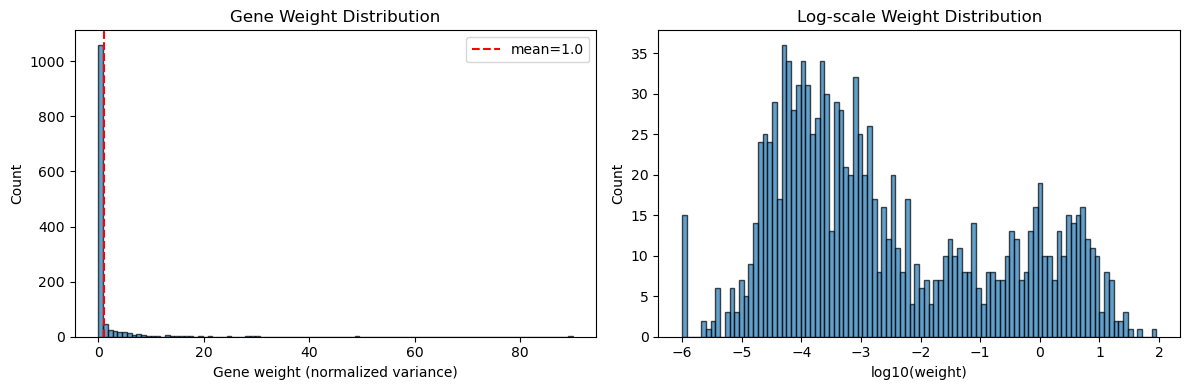

In [9]:
# 3.5 Visualize weight distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(gene_weights, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Gene weight (normalized variance)')
axes[0].set_ylabel('Count')
axes[0].set_title('Gene Weight Distribution')
axes[0].axvline(1.0, color='red', ls='--', label='mean=1.0')
axes[0].legend()

axes[1].hist(np.log10(gene_weights + 1e-6), bins=100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log10(weight)')
axes[1].set_ylabel('Count')
axes[1].set_title('Log-scale Weight Distribution')

plt.tight_layout()
plt.savefig(save_dir / 'gene_weights_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

np.save(save_dir / 'gene_weights.npy', gene_weights)
gene_weights_tensor = torch.tensor(gene_weights, dtype=torch.float32, device=device)

## 4. Load & Align GRN M Matrix

In [10]:
M_df = pd.read_csv(M_MATRIX_CSV, index_col=0)
print(f'Raw M: {M_df.shape} (targets x TFs)')

scgpt_genes = adata.var_names.tolist()
n_genes = len(scgpt_genes)
gene_to_idx = {g: i for i, g in enumerate(scgpt_genes)}

M_aligned = np.zeros((n_genes, n_genes), dtype=np.float32)
n_edges = 0
for tf in M_df.columns:
    if tf not in gene_to_idx:
        continue
    j = gene_to_idx[tf]
    for target in M_df.index:
        if target not in gene_to_idx:
            continue
        val = M_df.loc[target, tf]
        if val != 0:
            M_aligned[gene_to_idx[target], j] = val
            n_edges += 1

if M_NORMALIZE:
    row_norms = np.abs(M_aligned).sum(axis=1, keepdims=True)
    row_norms = np.where(row_norms > 0, row_norms, 1.0)
    M_aligned = M_aligned / row_norms

M_tensor = torch.tensor(M_aligned, dtype=torch.float32, device=device)
np.save(save_dir / 'M_aligned.npy', M_aligned)
print(f'Edges mapped: {n_edges}, M_tensor: {M_tensor.shape}')

Raw M: (1513, 131) (targets x TFs)
Edges mapped: 3509, M_tensor: torch.Size([1251, 1251])


## 5. GRN-Biased Model (per-layer alpha)

In [11]:
class GRNAttentionBias(nn.Module):
    def __init__(self, original_attn, M_grn, alpha_init=1.0):
        super().__init__()
        self.original_attn = original_attn
        self.M_grn = M_grn
        self.alpha = nn.Parameter(torch.tensor(alpha_init, dtype=torch.float32))
        self._current_gene_indices = None
    
    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            original = self.__dict__.get('_modules', {}).get('original_attn')
            if original is not None:
                return getattr(original, name)
            raise
    
    def forward(self, query, key, value, key_padding_mask=None,
                need_weights=False, attn_mask=None, **kwargs):
        seq_len = query.size(0)
        if self._current_gene_indices is not None:
            idx = self._current_gene_indices
            grn_bias = self.alpha * self.M_grn[idx][:, idx]
        else:
            grn_bias = self.alpha * self.M_grn[:seq_len, :seq_len]
        attn_mask = grn_bias if attn_mask is None else attn_mask + grn_bias
        return self.original_attn(
            query, key, value,
            key_padding_mask=key_padding_mask,
            need_weights=need_weights,
            attn_mask=attn_mask, **kwargs
        )

In [12]:
# 5.2 Build model, load pretrained, patch attention
load_param_prefixs = ['encoder', 'value_encoder', 'transformer_encoder']
model_file = Path(model_dir) / 'best_model.pt'
vocab_file = Path(model_dir) / 'vocab.json'

vocab = GeneVocab.from_file(vocab_file)
for s in special_tokens:
    if s not in vocab:
        vocab.append_token(s)

adata.var['id_in_vocab'] = [1 if gene in vocab else -1 for gene in adata.var_names]
n_matched = np.sum(np.array(adata.var['id_in_vocab']) >= 0)
print(f'Vocab match: {n_matched}/{adata.shape[1]}')

genes = adata.var_names.tolist()
gene_ids = np.array([vocab[gene] if gene in vocab else vocab['<pad>'] for gene in genes], dtype=int)
n_genes = len(genes)
ntokens = len(vocab)

model = TransformerGenerator(
    ntokens, embsize, nhead, d_hid, nlayers,
    nlayers_cls=n_layers_cls, n_cls=1, vocab=vocab, dropout=dropout,
    pad_token=pad_token, pad_value=pad_value, pert_pad_id=pert_pad_id,
    use_fast_transformer=False,
)

pretrained_dict = torch.load(model_file)
model_dict = model.state_dict()
filtered_dict = {
    k: v for k, v in pretrained_dict.items()
    if any(k.startswith(prefix) for prefix in load_param_prefixs)
    and k in model_dict and v.shape == model_dict[k].shape
}
model.load_state_dict(filtered_dict, strict=False)
print(f'Loaded {len(filtered_dict)} pretrained tensors')

# Patch attention
patched_attns = []
alpha_params = []
for layer_idx, layer in enumerate(model.transformer_encoder.layers):
    wrapped = GRNAttentionBias(layer.self_attn, M_tensor, alpha_init=ALPHA_INIT)
    layer.self_attn = wrapped
    patched_attns.append(wrapped)
    alpha_params.append(wrapped.alpha)
    print(f'  Layer {layer_idx}: patched (alpha_init={ALPHA_INIT})')

model.to(device)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

def set_gene_indices(gene_indices):
    for attn in patched_attns:
        attn._current_gene_indices = gene_indices

Vocab match: 1146/1251
Loaded 4 pretrained tensors
  Layer 0: patched (alpha_init=1.0)
  Layer 1: patched (alpha_init=1.0)
  Layer 2: patched (alpha_init=1.0)
  Layer 3: patched (alpha_init=1.0)
Total parameters: 8,679,943


## 6. Dataset

In [13]:
class scGPTPerturbDataset(Dataset):
    def __init__(self, adata, ctrl_X, split='train'):
        self.adata = adata[adata.obs['split'] == split].copy()
        self.X = self.adata.X.toarray() if hasattr(self.adata.X, 'toarray') else self.adata.X
        self.conditions = self.adata.obs['condition'].values
        self.gene_names = self.adata.var_names.tolist()
        self.gene_to_idx = {gene: i for i, gene in enumerate(self.gene_names)}
        self.ctrl_X = ctrl_X

    def __len__(self):
        return len(self.adata)

    def __getitem__(self, idx):
        target_expr = torch.tensor(self.X[idx], dtype=torch.float32)
        condition = self.conditions[idx]
        pert_flags = torch.zeros(len(self.gene_names), dtype=torch.long)
        if condition != 'ctrl':
            for p in condition.split('+'):
                if p != 'ctrl' and p in self.gene_to_idx:
                    pert_flags[self.gene_to_idx[p]] = 1
        random_ctrl_idx = np.random.randint(0, len(self.ctrl_X))
        ori_expr = torch.tensor(self.ctrl_X[random_ctrl_idx], dtype=torch.float32)
        return ori_expr, pert_flags, target_expr, condition

train_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split='train')
val_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split='val')
test_dataset = scGPTPerturbDataset(adata, global_ctrl_X, split='test')

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_dataset, batch_size=eval_batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=eval_batch_size, shuffle=False)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')

Train: 47192, Val: 11196, Test: 30969


## 7. Loss Functions

Three components:

| Component | Source | Formula | Purpose |
|---|---|---|---|
| Variance-weighted delta MSE | This work | `w_g * (pred_delta_g - true_delta_g)^2` | Gene importance from cross-perturbation variability |
| Autofocus | GEARS (Roohani 2024) | `(per_cell_weighted_MSE)^gamma` | Self-calibrating: large-effect genes amplified |
| Direction-aware | GEARS | `1 - cos(pred_delta, true_delta)` | Penalizes wrong perturbation direction |

In [14]:
def perturbation_loss(pred, target, ctrl_input, gene_weights, gamma=2.0, lambda_dir=0.05):
    """
    L = L_autofocus + lambda * L_direction
    
    L_autofocus = mean_B( (mean_G( w_g * (delta_pred_g - delta_true_g)^2 ))^gamma )
    L_direction = mean_B( 1 - cos(delta_pred, delta_true) )
    """
    pred_delta = pred - ctrl_input
    true_delta = target - ctrl_input
    
    # Variance-weighted per-gene MSE
    per_gene_mse = (pred_delta - true_delta) ** 2                    # (B, G)
    weighted_mse = per_gene_mse * gene_weights.unsqueeze(0)          # (B, G)
    
    # Autofocus: raise per-cell mean to power gamma
    per_cell_loss = weighted_mse.mean(dim=1)                         # (B,)
    if gamma != 1.0:
        L_autofocus = (per_cell_loss ** gamma).mean()
    else:
        L_autofocus = per_cell_loss.mean()
    
    # Direction-aware loss
    cos_sim = F.cosine_similarity(pred_delta, true_delta, dim=1)     # (B,)
    L_direction = (1.0 - cos_sim).mean()
    
    loss = L_autofocus + lambda_dir * L_direction
    return loss, L_autofocus.item(), L_direction.item()

print(f'Loss: var-weighted delta MSE + autofocus(gamma={GAMMA}) + direction(lambda={LAMBDA_DIR})')

Loss: var-weighted delta MSE + autofocus(gamma=2.0) + direction(lambda=0.05)


In [15]:
# 7.2 Optimizer
alpha_param_ids = {id(p) for p in alpha_params}
base_params = [p for p in model.parameters() if id(p) not in alpha_param_ids]

optimizer = torch.optim.Adam([
    {'params': base_params, 'lr': lr},
    {'params': alpha_params, 'lr': alpha_lr, 'weight_decay': 0.0},
], lr=lr)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=amp)

print(f'base_lr={lr}, alpha_lr={alpha_lr}, CosineAnnealing T={epochs}')

base_lr=0.0001, alpha_lr=0.01, CosineAnnealing T=25


In [16]:
# 7.3 Training epoch
def train_epoch(model, train_loader, epoch_num):
    model.train()
    total_loss = 0.0
    total_af = 0.0
    total_dir = 0.0
    start_time = time.time()
    num_batches = len(train_loader)
    alpha_grad_norms = []

    for batch_idx, (ori_expr, pert_flags, target_expr, conditions) in enumerate(train_loader):
        bs = ori_expr.size(0)
        ori_gene_values = ori_expr.to(device)
        pert_flags_dev = pert_flags.to(device)
        target_gene_values = target_expr.to(device)

        input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
        if len(input_gene_ids) > max_seq_len:
            input_gene_ids = torch.randperm(len(input_gene_ids), device=device)[:max_seq_len]
        
        set_gene_indices(input_gene_ids)

        input_values = ori_gene_values[:, input_gene_ids]
        input_pert_flags = pert_flags_dev[:, input_gene_ids]
        target_values = target_gene_values[:, input_gene_ids]

        mapped_ids = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).repeat(bs, 1).to(device)
        src_key_padding_mask = torch.zeros_like(input_values, dtype=torch.bool, device=device)

        with torch.cuda.amp.autocast(enabled=amp):
            output_dict = model(
                mapped_ids, input_values, input_pert_flags,
                src_key_padding_mask=src_key_padding_mask,
                CLS=CLS, CCE=CCE, MVC=MVC, ECS=ECS,
            )
            output_values = output_dict['mlm_output']
            w = gene_weights_tensor[input_gene_ids]
            loss, af_val, dir_val = perturbation_loss(
                output_values, target_values, input_values,
                w, gamma=GAMMA, lambda_dir=LAMBDA_DIR
            )

        model.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        if batch_idx % log_interval == 0:
            for ap in alpha_params:
                if ap.grad is not None:
                    alpha_grad_norms.append(ap.grad.item())
        
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        total_af += af_val
        total_dir += dir_val
        
        if batch_idx % log_interval == 0 and batch_idx > 0:
            n = log_interval
            alphas_str = ' '.join([f'{a.item():.3f}' for a in alpha_params])
            logger.info(
                f'| ep {epoch_num} batch {batch_idx:3d}/{num_batches:3d} | '
                f'loss {total_loss/n:.4f} af={total_af/n:.4f} dir={total_dir/n:.4f} | '
                f'alphas [{alphas_str}]'
            )
            total_loss = total_af = total_dir = 0.0
            start_time = time.time()
    
    return alpha_grad_norms

In [17]:
# 7.4 Evaluation
def eval_perturb(loader, model, device):
    model.eval()
    pert_cat, pred, truth = [], [], []
    input_gene_ids = torch.arange(n_genes, device=device, dtype=torch.long)
    mapped_base = map_raw_id_to_vocab_id(input_gene_ids, gene_ids).to(device)
    set_gene_indices(input_gene_ids)

    with torch.no_grad():
        for ori_expr, pert_flags, target_expr, conditions in loader:
            bs = ori_expr.size(0)
            input_values = ori_expr.to(device)
            input_pert_flags = pert_flags.to(device)
            target_values = target_expr.to(device)
            mapped_ids = mapped_base.repeat(bs, 1)
            src_key_padding_mask = torch.zeros_like(input_values, dtype=torch.bool, device=device)

            with torch.cuda.amp.autocast(enabled=amp):
                output_dict = model(
                    mapped_ids, input_values, input_pert_flags,
                    src_key_padding_mask=src_key_padding_mask,
                    CLS=CLS, CCE=CCE, MVC=MVC, ECS=ECS,
                )
            pert_cat.extend(conditions)
            pred.append(output_dict['mlm_output'].cpu().numpy())
            truth.append(target_values.cpu().numpy())

    return {
        'pert_cat': np.array(pert_cat),
        'pred': np.concatenate(pred).astype(np.float64),
        'truth': np.concatenate(truth).astype(np.float64),
    }

def compute_metrics_allgenes(res_dict):
    pert_cats = res_dict['pert_cat']
    preds = res_dict['pred']
    truths = res_dict['truth']
    corrs = []
    for pert in np.unique(pert_cats):
        if pert == 'ctrl':
            continue
        idx = np.where(pert_cats == pert)[0]
        if len(idx) == 0:
            continue
        r, _ = pearsonr(preds[idx].mean(axis=0), truths[idx].mean(axis=0))
        if not np.isnan(r):
            corrs.append(r)
    return {'pearson_all_genes': np.mean(corrs)}

In [ ]:
# 7.5 Training loop
best_val_corr = 0
best_model_epoch = 0
patience = 0
alpha_history = []
alpha_grad_history = []

for epoch in range(1, epochs + 1):
    t0 = time.time()
    grad_norms = train_epoch(model, train_loader, epoch)
    alpha_grad_history.append(grad_norms)
    
    torch.cuda.empty_cache()
    
    val_res = eval_perturb(valid_loader, model, device)
    val_metrics = compute_metrics_allgenes(val_res)
    val_score = val_metrics['pearson_all_genes']
    
    cur_alphas = [a.item() for a in alpha_params]
    alpha_history.append(cur_alphas)
    
    alphas_str = ' '.join([f'{a:.3f}' for a in cur_alphas])
    grad_str = f'mean|grad|={np.mean(np.abs(grad_norms)):.4f}' if grad_norms else 'no_grad'
    logger.info(
        f'Epoch {epoch:2d} | {time.time()-t0:.0f}s | '
        f'val PCC(all): {val_score:.4f} | alphas [{alphas_str}] | {grad_str}'
    )

    if val_score > best_val_corr:
        best_val_corr = val_score
        torch.save(model.state_dict(), save_dir / 'best_model.pt')
        best_model_epoch = epoch
        logger.info(f'  -> New best (PCC={val_score:.4f}), saved epoch {epoch}')
        patience = 0
    else:
        patience += 1
        if patience >= early_stop:
            logger.info(f'Early stopping at epoch {epoch}')
            break
    scheduler.step()

model.load_state_dict(torch.load(save_dir / 'best_model.pt'))
best_model = model
print(f'Best model loaded (epoch {best_model_epoch}, val PCC={best_val_corr:.4f})')

scGPT - INFO - | ep 1 batch  50/185 | loss 3.9083 af=3.8672 dir=0.8213 | alphas [1.297 1.364 1.379 1.347]
scGPT - INFO - | ep 1 batch 100/185 | loss 1.7141 af=1.6745 dir=0.7930 | alphas [1.468 1.701 1.709 1.560]
scGPT - INFO - | ep 1 batch 150/185 | loss 1.4483 af=1.4094 dir=0.7773 | alphas [1.181 1.617 1.610 1.559]
scGPT - INFO - Epoch  1 | 189s | val PCC(all): 0.7908 | alphas [0.861 1.682 1.676 1.628] | mean|grad|=0.0000
scGPT - INFO -   -> New best (PCC=0.7908), saved epoch 1
scGPT - INFO - | ep 2 batch  50/185 | loss 1.3116 af=1.2749 dir=0.7336 | alphas [0.289 1.620 1.635 1.581]
scGPT - INFO - | ep 2 batch 100/185 | loss 1.1754 af=1.1415 dir=0.6776 | alphas [-0.130 1.652 1.610 1.595]
scGPT - INFO - | ep 2 batch 150/185 | loss 1.1076 af=1.0761 dir=0.6309 | alphas [-0.045 1.825 1.690 1.700]
scGPT - INFO - Epoch  2 | 188s | val PCC(all): 0.9239 | alphas [0.030 1.909 1.761 1.806] | mean|grad|=0.0000
scGPT - INFO -   -> New best (PCC=0.9239), saved epoch 2
scGPT - INFO - | ep 3 batch  5

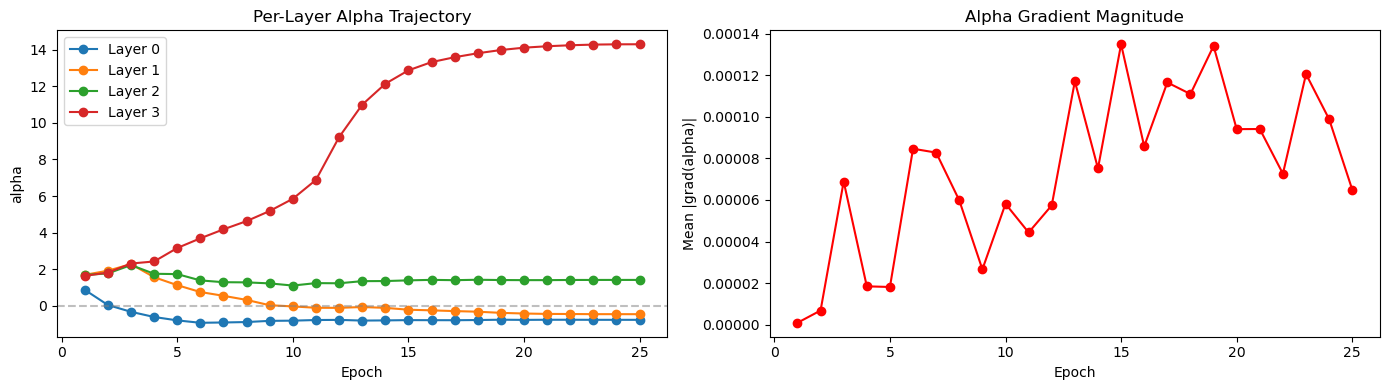

In [27]:
# 7.6 Alpha trajectory + gradient diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

alpha_arr = np.array(alpha_history)
for li in range(alpha_arr.shape[1]):
    axes[0].plot(range(1, len(alpha_arr)+1), alpha_arr[:, li], 'o-', label=f'Layer {li}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('alpha')
axes[0].set_title('Per-Layer Alpha Trajectory')
axes[0].legend()
axes[0].axhline(0, ls='--', c='gray', alpha=0.5)

mean_grads = [np.mean(np.abs(g)) if g else 0 for g in alpha_grad_history]
axes[1].plot(range(1, len(mean_grads)+1), mean_grads, 'o-', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean |grad(alpha)|')
axes[1].set_title('Alpha Gradient Magnitude')

plt.tight_layout()
plt.savefig(save_dir / 'alpha_trajectory_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Test Evaluation

In [28]:
def compute_metrics_top20de(res_dict, ctrl_mean):
    pert_cats = res_dict['pert_cat']
    preds = res_dict['pred']
    truths = res_dict['truth']
    per_pert = {}
    corrs_top20, corrs_all, mse_top20 = [], [], []
    
    for pert in np.unique(pert_cats):
        if pert == 'ctrl':
            continue
        idx = np.where(pert_cats == pert)[0]
        if len(idx) < 2:
            continue
        mean_pred = preds[idx].mean(axis=0)
        mean_truth = truths[idx].mean(axis=0)
        pred_delta = mean_pred - ctrl_mean
        truth_delta = mean_truth - ctrl_mean
        top20_idx = np.argsort(np.abs(truth_delta))[-20:]
        
        r_top20, _ = pearsonr(pred_delta[top20_idx], truth_delta[top20_idx])
        r_all, _ = pearsonr(pred_delta, truth_delta)
        mse = np.mean((pred_delta[top20_idx] - truth_delta[top20_idx]) ** 2)
        
        if not np.isnan(r_top20):
            corrs_top20.append(r_top20)
            corrs_all.append(r_all)
            mse_top20.append(mse)
            per_pert[pert] = {
                'pcc_top20': r_top20, 'pcc_all': r_all,
                'mse_top20': mse, 'n_cells': len(idx),
            }
    
    return {
        'mean_pcc_top20': np.mean(corrs_top20),
        'median_pcc_top20': np.median(corrs_top20),
        'std_pcc_top20': np.std(corrs_top20),
        'mean_pcc_all': np.mean(corrs_all),
        'mean_mse_top20': np.mean(mse_top20),
        'n_perturbations': len(corrs_top20),
        'per_pert': per_pert,
    }

In [29]:
ctrl_cells = adata[adata.obs['condition'] == 'ctrl']
ctrl_X = ctrl_cells.X.toarray() if hasattr(ctrl_cells.X, 'toarray') else ctrl_cells.X
ctrl_mean = ctrl_X.mean(axis=0)

test_res = eval_perturb(test_loader, best_model, device)
metrics = compute_metrics_top20de(test_res, ctrl_mean)

print('=' * 60)
print('S2 v2: var-weighted autofocus + direction loss')
print('=' * 60)
print(f'PCC (top-20 DE, mean):   {metrics["mean_pcc_top20"]:.4f}')
print(f'PCC (top-20 DE, median): {metrics["median_pcc_top20"]:.4f}')
print(f'PCC (top-20 DE, std):    {metrics["std_pcc_top20"]:.4f}')
print(f'MSE (top-20 DE):         {metrics["mean_mse_top20"]:.4f}')
print(f'N perturbations:         {metrics["n_perturbations"]}')
print(f'Learned alphas:          {[f"{a.item():.4f}" for a in alpha_params]}')
print()
print('BASELINES:')
print(f'  S1 vanilla (leakfix):  PCC 0.5411 (mean), 0.6395 (median)')
print(f'  S2 v1 (raw MSE):      PCC 0.5379 (mean), 0.5737 (median)')

S2 v2: var-weighted autofocus + direction loss
PCC (top-20 DE, mean):   0.5872
PCC (top-20 DE, median): 0.6324
PCC (top-20 DE, std):    0.3728
MSE (top-20 DE):         0.4313
N perturbations:         114
Learned alphas:          ['-0.7837', '-0.4353', '1.3930', '14.1231']

BASELINES:
  S1 vanilla (leakfix):  PCC 0.5411 (mean), 0.6395 (median)
  S2 v1 (raw MSE):      PCC 0.5379 (mean), 0.5737 (median)


In [30]:
# Save
save_metrics = {k: v for k, v in metrics.items() if k != 'per_pert'}
save_metrics['learned_alphas'] = [a.item() for a in alpha_params]
save_metrics['alpha_history'] = alpha_history
save_metrics['config'] = {
    'GAMMA': GAMMA, 'LAMBDA_DIR': LAMBDA_DIR,
    'ALPHA_INIT': ALPHA_INIT, 'alpha_lr': alpha_lr, 'base_lr': lr,
}
with open(save_dir / 'test_metrics.json', 'w') as f:
    json.dump(save_metrics, f, indent=2)

results_df = pd.DataFrame([
    {'perturbation': pert, 'model': 'scGPT_grn_bias_v2', **m}
    for pert, m in metrics['per_pert'].items()
])
results_df.to_csv(save_dir / 'per_perturbation_results.csv', index=False)
print(f'Saved {len(results_df)} perturbation results')

Saved 114 perturbation results


## 9. Magnitude Calibration

Slope: mean=0.360, median=0.282 (ideal=1.0)


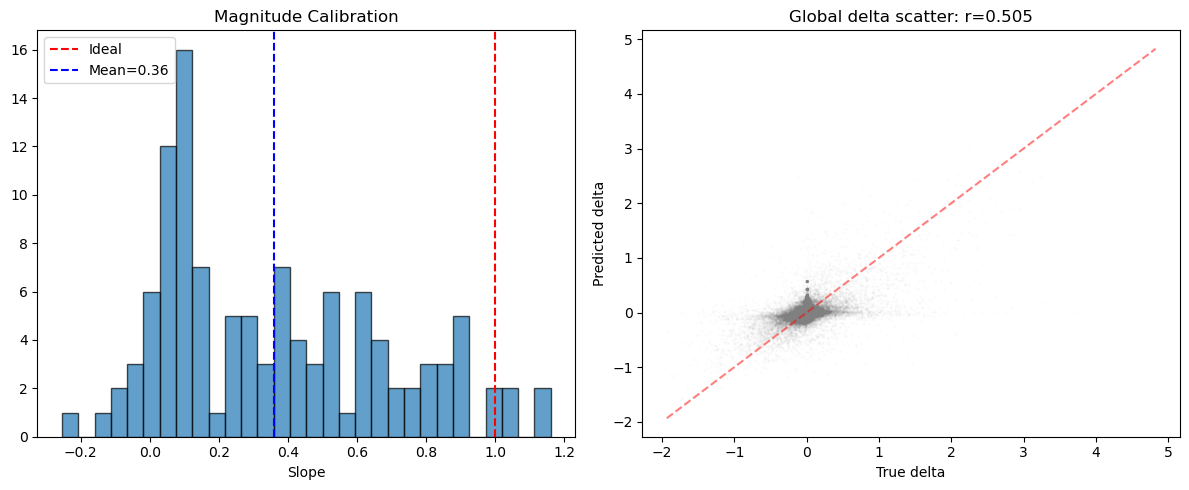

In [31]:
pert_cats = test_res['pert_cat']
preds = test_res['pred']
truths = test_res['truth']

all_pred_deltas, all_true_deltas = [], []
slopes = []

for pert in np.unique(pert_cats):
    if pert == 'ctrl':
        continue
    idx = np.where(pert_cats == pert)[0]
    if len(idx) < 2:
        continue
    pd_ = preds[idx].mean(0) - ctrl_mean
    td_ = truths[idx].mean(0) - ctrl_mean
    all_pred_deltas.append(pd_)
    all_true_deltas.append(td_)
    mask = np.abs(td_) > 0.1
    if mask.sum() > 5:
        slope = np.polyfit(td_[mask], pd_[mask], 1)[0]
        slopes.append(slope)

print(f'Slope: mean={np.mean(slopes):.3f}, median={np.median(slopes):.3f} (ideal=1.0)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(slopes, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(1.0, color='red', ls='--', label='Ideal')
axes[0].axvline(np.mean(slopes), color='blue', ls='--', label=f'Mean={np.mean(slopes):.2f}')
axes[0].set_xlabel('Slope')
axes[0].set_title('Magnitude Calibration')
axes[0].legend()

all_pd = np.concatenate(all_pred_deltas)
all_td = np.concatenate(all_true_deltas)
r_global, _ = pearsonr(all_pd, all_td)
axes[1].scatter(all_td, all_pd, alpha=0.02, s=1, c='gray')
lims = [min(all_td.min(), all_pd.min()), max(all_td.max(), all_pd.max())]
axes[1].plot(lims, lims, 'r--', alpha=0.5)
axes[1].set_xlabel('True delta')
axes[1].set_ylabel('Predicted delta')
axes[1].set_title(f'Global delta scatter: r={r_global:.3f}')

plt.tight_layout()
plt.savefig(save_dir / 'magnitude_calibration.png', dpi=150)
plt.show()

## 10. Comparison

In [32]:
import glob

comparisons = {}
baseline_dirs = sorted(glob.glob('./save/dev_perturb_norman_leakfix-*/'))
if baseline_dirs:
    csv = Path(baseline_dirs[-1]) / 'per_perturbation_results.csv'
    if csv.exists():
        comparisons['S1 vanilla'] = pd.read_csv(csv)

v1_dirs = sorted(glob.glob('./save/dev_perturb_norman_grn_bias-*/'))
if v1_dirs:
    csv = Path(v1_dirs[-1]) / 'per_perturbation_results.csv'
    if csv.exists():
        comparisons['S2 v1'] = pd.read_csv(csv)

comparisons['S2 v2'] = results_df

for name, df in comparisons.items():
    print(f'{name}: {len(df)} perts, mean PCC={df["pcc_top20"].mean():.4f}')

S1 vanilla: 114 perts, mean PCC=0.5411
S2 v1: 114 perts, mean PCC=0.5379
S2 v2: 114 perts, mean PCC=0.5872


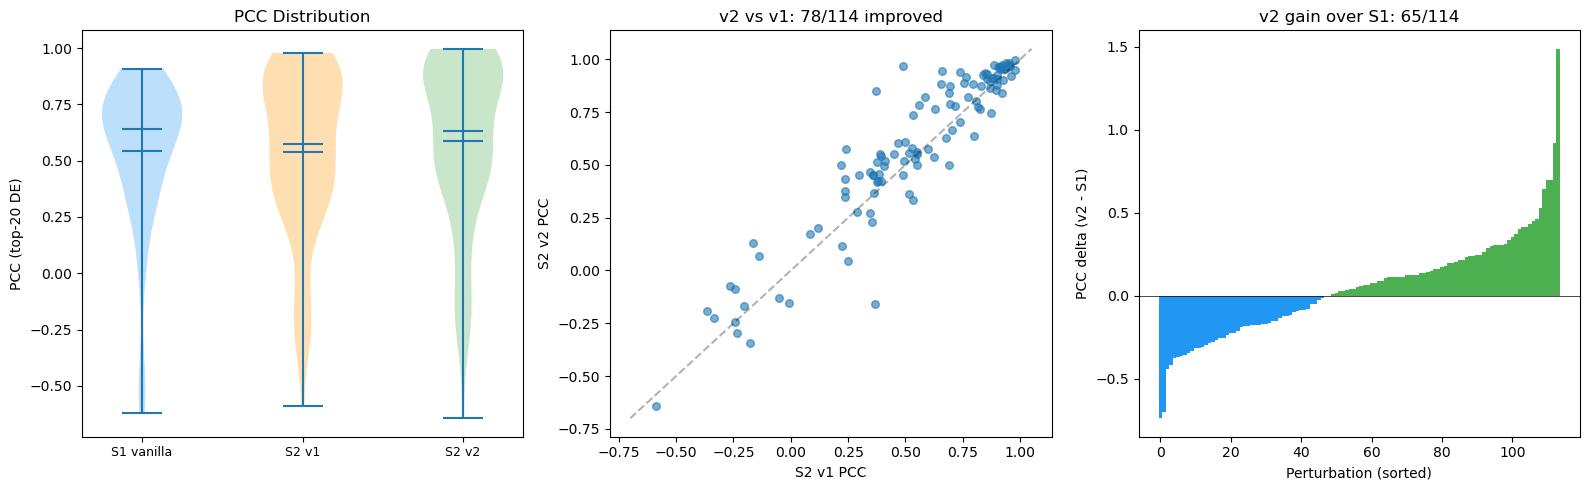


=== SUMMARY ===
S1 vanilla            mean=0.5411  median=0.6395
S2 v1                 mean=0.5379  median=0.5737
S2 v2                 mean=0.5872  median=0.6324


In [33]:
if len(comparisons) >= 2:
    shared = sorted(set.intersection(*[set(df['perturbation']) for df in comparisons.values()]))
    labels = list(comparisons.keys())
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    colors = ['#2196F3', '#FF9800', '#4CAF50'][:len(labels)]
    
    data = [comparisons[l].set_index('perturbation').loc[shared, 'pcc_top20'].values for l in labels]
    parts = axes[0].violinplot(data, showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
    axes[0].set_xticks(range(1, len(labels)+1))
    axes[0].set_xticklabels(labels, fontsize=9)
    axes[0].set_ylabel('PCC (top-20 DE)')
    axes[0].set_title('PCC Distribution')
    
    if 'S2 v1' in comparisons:
        v1_pcc = comparisons['S2 v1'].set_index('perturbation').loc[shared, 'pcc_top20']
        v2_pcc = comparisons['S2 v2'].set_index('perturbation').loc[shared, 'pcc_top20']
        axes[1].scatter(v1_pcc, v2_pcc, alpha=0.6, s=30)
        axes[1].plot([-0.7, 1.05], [-0.7, 1.05], 'k--', alpha=0.3)
        n_imp = (v2_pcc.values > v1_pcc.values).sum()
        axes[1].set_xlabel('S2 v1 PCC')
        axes[1].set_ylabel('S2 v2 PCC')
        axes[1].set_title(f'v2 vs v1: {n_imp}/{len(shared)} improved')
    
    if 'S1 vanilla' in comparisons:
        s1 = comparisons['S1 vanilla'].set_index('perturbation').loc[shared, 'pcc_top20']
        v2 = comparisons['S2 v2'].set_index('perturbation').loc[shared, 'pcc_top20']
        delta = (v2 - s1).sort_values()
        c = ['#2196F3' if d < 0 else '#4CAF50' for d in delta.values]
        axes[2].bar(range(len(delta)), delta.values, color=c, width=1.0)
        axes[2].set_xlabel('Perturbation (sorted)')
        axes[2].set_ylabel('PCC delta (v2 - S1)')
        axes[2].set_title(f'v2 gain over S1: {(delta > 0).sum()}/{len(delta)}')
        axes[2].axhline(0, color='black', lw=0.5)
    
    plt.tight_layout()
    plt.savefig(save_dir / 'v2_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n=== SUMMARY ===')
    for l in labels:
        v = comparisons[l].set_index('perturbation').loc[shared, 'pcc_top20']
        print(f'{l:20s}  mean={v.mean():.4f}  median={v.median():.4f}')

In [34]:
print('=' * 50)
print('OUTPUT FILES')
print('=' * 50)
for f in sorted(os.listdir(save_dir)):
    size = os.path.getsize(save_dir / f) / 1e6
    print(f'  {f} ({size:.1f} MB)')

OUTPUT FILES
  .ipynb_checkpoints (0.0 MB)
  M_aligned.npy (6.3 MB)
  alpha_trajectory_v2.png (0.1 MB)
  best_model.pt (34.8 MB)
  gene_weights.npy (0.0 MB)
  gene_weights_distribution.png (0.1 MB)
  magnitude_calibration.png (0.1 MB)
  per_perturbation_results.csv (0.0 MB)
  run.log (0.0 MB)
  test_metrics.json (0.0 MB)
  v2_comparison.png (0.1 MB)
